# Influenta factorilor demografici si economici asupra emisiilor CO2 la nivel global

## Introducere

Acest notebook prezintă analiza relației dintre factorii economici și emisiile de CO2 la nivel global.

Scopul este identificarea variabilelor care influențează emisiile și evidențierea unor tipare economice relevante.

## Importuri

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Incărcare date

In [38]:
df = pd.read_excel("../data/CO2_emissions_factors.xlsx")
df.head()

,Country,CO2_emissions,gdp_pc_ppp,urban_population,total_population,fdi,renewable_energy,trade_in_services
0,Afghanistan,0.250620,357.261153,26.616,40578842,NaN,20.0,NaN
1,Albania,1.590840,6846.426694,63.799,2777689,1.441382e+09,41.9,39.607562
2,Algeria,4.238998,4961.552577,74.772,45477389,2.417960e+08,0.3,5.068396
3,Andorra,5.311056,42414.059009,87.811,79705,5.939814e+08,18.7,94.434891
4,Angola,0.591805,2929.694455,68.081,35635029,-6.598653e+09,52.9,10.899534


## Tratarea valorilor lipsă

In [39]:
df.isnull().sum()

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Country              0
CO2_emissions        0
gdp_pc_ppp           0
urban_population     0
total_population     0
fdi                  0
renewable_energy     0
trade_in_services    0
dtype: int64

Valorile lipsă au fost tratate prin imputare cu mediana pentru toate variabilele numerice.
Această metodă este robustă la valori extreme și păstrează distribuția reală a datelor,
fiind preferată în analiza econometrică față de media aritmetică.

## Detectarea valorilor extreme

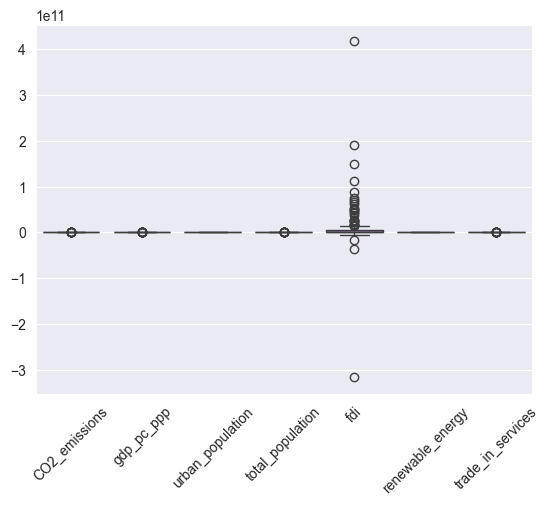

In [40]:
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

Analiza boxplot indică prezența unor valori extreme, în special pentru variabile economice precum FDI.

Aceste valori reflectă diferențe semnificative între țări și pot influența rezultatele modelelor statistice.

## Eliminarea variabilei categorice

In [41]:
df = df.drop(columns=["Country"])

Coloana "Country" a fost eliminată deoarece nu are semnificație numerică și nu este relevantă pentru modelarea statistică.

## Transformări econometrice

In [42]:
df["log_CO2"] = np.log(df["CO2_emissions"] + 1)
df["log_GDP"] = np.log(df["gdp_pc_ppp"] + 1)
df["log_population"] = np.log(df["total_population"] + 1)
df["asinh_fdi"] = np.arcsinh(df["fdi"])

scaler = StandardScaler()
percent_cols = ["urban_population", "trade_in_services", "renewable_energy"]
df[percent_cols] = scaler.fit_transform(df[percent_cols])

Transformările aplicate au redus asimetria distribuțiilor și impactul valorilor extreme.

Variabilele devin mai apropiate de o distribuție normală, ceea ce îmbunătățește stabilitatea și acuratețea modelului.

## Gruparea datelor

In [43]:
df["GDP_Group"] = pd.qcut(df["gdp_pc_ppp"], 4)

df.groupby("GDP_Group", observed=False)["CO2_emissions"].mean()

GDP_Group
(250.63299999999998, 2368.593]    0.491995
(2368.593, 6705.146]              2.366470
(6705.146, 21567.93]              5.155708
(21567.93, 123719.659]            9.688008
Name: CO2_emissions, dtype: float64

Rezultatele arată că emisiile de CO2 cresc odată cu nivelul PIB-ului.

Această relație sugerează că economiile mai dezvoltate au un impact mai ridicat asupra mediului.

## Regresie liniară multiplă

In [44]:
X = df[[
    "log_GDP",
    "log_population",
    "asinh_fdi",
    "urban_population",
    "trade_in_services",
    "renewable_energy"
]]

y = df["log_CO2"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                log_CO2   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     61.04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           2.14e-31
Time:                        14:52:22   Log-Likelihood:                -50.819
No. Observations:                 108   AIC:                             115.6
Df Residuals:                     101   BIC:                             134.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.0960      0.537     -5.761      0.000      -4.162      -2.030
log_GDP               0.4223      0.043      9.717      0.000       0.336       0.508
log_population        0.0416      0.021      2.012      0.047       0.001       0.083
asinh_fdi            -0.0001      0.003     -0.041      0.968      -0.006       0.006
urban_population      0.0013      0.056      0.023      0.982      -0.111       0.113
trade_in_services    -0.0394      0.042     -0.928      0.356      -0.124       0.045
renewable_energy     -0.2343      0.045     -5.206      0.000      -0.324      -0.145
==============================================================================
Omnibus:                       33.864   Durbin-Watson:                   2.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.410
Skew:                           1.359   Prob(JB):                     1.26e-13
Kurtosis:                       5.411   Cond. No.                         376.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretare

Modelul de regresie evidențiază o relație semnificativă între factorii economici și emisiile de CO2.

PIB-ul are un efect pozitiv asupra emisiilor, în timp ce variabile precum energia regenerabilă contribuie la reducerea acestora.

Modelul explică o proporție semnificativă din variația emisiilor (R²), ceea ce indică o performantă bună a modelului.


## Clusterizare

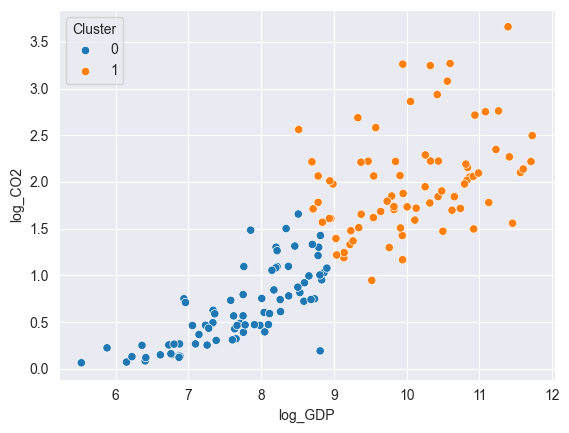

In [45]:
X_cluster = df[["log_GDP", "log_CO2"]]

kmeans = KMeans(n_clusters=2)
df["Cluster"] = kmeans.fit_predict(X_cluster)

sns.scatterplot(x=df["log_GDP"], y=df["log_CO2"], hue=df["Cluster"])
plt.show()

### Interpretare

Clusterizarea evidențiază existența unor grupuri distincte de țări în funcție de nivelul PIB și al emisiilor de CO2.

Rezultatele sugerează diferențe structurale între economii, confirmând heterogenitatea datelor la nivel global.

## Analiza performanței modelului pe clustere

### Predicții + eroare


In [49]:
X_full = sm.add_constant(X)
df["Predicted_log_CO2"] = model.predict(X_full)

df["Predicted_CO2"] = np.exp(df["Predicted_log_CO2"]) - 1

df["Error"] = df["CO2_emissions"] - df["Predicted_CO2"]

np.int64(0)

### Analiză pe clustere

In [52]:
cluster_analysis = df.groupby("Cluster").agg({
    "CO2_emissions": "mean",
    "Predicted_CO2": "mean",
    "Error": ["mean", "std"]
})

print(cluster_analysis)

        CO2_emissions Predicted_CO2     Error          
                 mean          mean      mean       std
Cluster                                                
0            1.084516      1.310674 -0.226158  0.550599
1            7.714380      6.177534  1.536845  5.723363


### Grafic REAL vs ESTIMAT

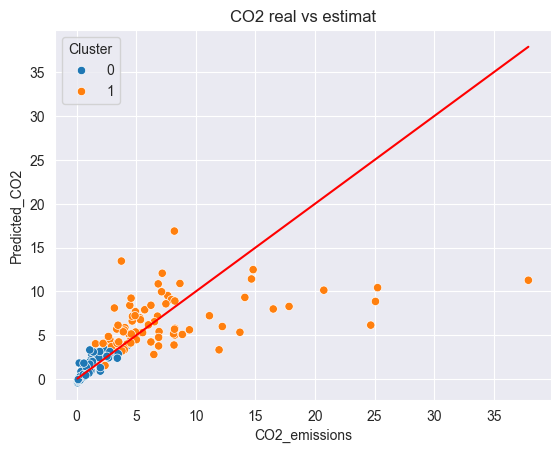

In [22]:
sns.scatterplot(
    x=df["CO2_emissions"],
    y=df["Predicted_CO2"],
    hue=df["Cluster"]
)

plt.plot(
    [df["CO2_emissions"].min(), df["CO2_emissions"].max()],
    [df["CO2_emissions"].min(), df["CO2_emissions"].max()],
    color='red'
)

plt.title("CO2 real vs estimat")
plt.show()

### Boxplot erori (FOARTE IMPORTANT)

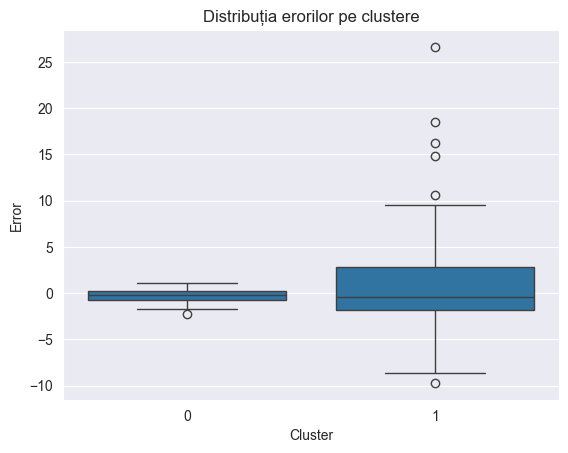

In [23]:
sns.boxplot(
    x=df["Cluster"],
    y=df["Error"]
)

plt.title("Distribuția erorilor pe clustere")
plt.show()

### Interpretare

Modelul de regresie nu performează uniform pentru toate grupurile de țări.

Pentru clusterul caracterizat prin niveluri mai reduse și mai omogene ale emisiilor,
valorile estimate sunt apropiate de cele reale, iar erorile sunt mici și compacte.

În schimb, pentru clusterul asociat cu emisii ridicate, se observă o dispersie mai mare a valorilor,
iar modelul înregistrează erori semnificative, inclusiv outlieri.

Acest rezultat sugerează existența unor relații non-lineare sau a unor factori suplimentari
care influențează emisiile de CO2 în economiile mai dezvoltate.

## Concluzii

Analiza realizată evidențiază existența unei relații semnificative între dezvoltarea economică și nivelul emisiilor de CO2.

Rezultatele modelului de regresie arată că PIB-ul are un impact pozitiv asupra emisiilor, în timp ce utilizarea energiei regenerabile contribuie la reducerea acestora.

Clusterizarea a confirmat existența unor grupuri distincte de țări, diferențiate în funcție de nivelul de dezvoltare economică și de intensitatea emisiilor.

Aceste rezultate sugerează că dezvoltarea economică este asociată cu un impact crescut asupra mediului, subliniind necesitatea unor politici sustenabile.

## Implicații practice

Rezultatele analizei pot fi utilizate pentru:

- formularea politicilor publice de mediu
- evaluarea impactului dezvoltării economice asupra emisiilor
- identificarea țărilor cu risc ridicat de poluare
- prioritizarea investițiilor în energie regenerabilă

În ansamblu, rezultatele indică faptul că dezvoltarea economică este asociată cu un impact semnificativ asupra mediului,
iar reducerea emisiilor depinde în mare măsură de tranziția către surse de energie sustenabile.

## Limitări și direcții viitoare

Modelul de regresie liniară nu captează complet relațiile non-lineare din date, în special pentru economiile cu emisii ridicate.

Modele de tip Machine Learning (ex: Random Forest, Gradient Boosting) ar putea îmbunătăți performanța și acuratețea predicțiilor.